In [1]:
!pip -q install gdown

import gdown
import numpy as np

In [2]:
ROI_FILE_ID = "1WWHm4aBVO_rPHFLmnKL7DFWXowRm7FDp"
SUBJECT_FILE_ID = "181QJvNZURrhtX-sWiywspf3LxKXjAidA"

In [3]:
gdown.download(
    id=ROI_FILE_ID,
    output="roi_timeseries_clean.npy",
    quiet=False
)

gdown.download(
    id=SUBJECT_FILE_ID,
    output="subjects_clean.npy",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1WWHm4aBVO_rPHFLmnKL7DFWXowRm7FDp
From (redirected): https://drive.google.com/uc?id=1WWHm4aBVO_rPHFLmnKL7DFWXowRm7FDp&confirm=t&uuid=923bc0ca-1442-4398-a130-695f91ce244f
To: /content/roi_timeseries_clean.npy
100%|██████████| 807M/807M [00:06<00:00, 125MB/s]
Downloading...
From: https://drive.google.com/uc?id=181QJvNZURrhtX-sWiywspf3LxKXjAidA
To: /content/subjects_clean.npy
100%|██████████| 11.3k/11.3k [00:00<00:00, 5.63MB/s]


'subjects_clean.npy'

In [4]:
X = np.load(
    "roi_timeseries_clean.npy",
    mmap_mode="r"
)

subjects = np.load(
    "subjects_clean.npy"
)

In [5]:
print("ROI data shape:", X.shape)
print("ROI data dtype:", X.dtype)
print("Subjects shape:", subjects.shape)
print("First 5 subjects:", subjects[:5])

ROI data shape: (467, 1200, 360)
ROI data dtype: float32
Subjects shape: (467,)
First 5 subjects: ['100307' '100408' '101006' '101107' '101309']


In [6]:
import numpy as np

n_subjects, n_timepoints, n_rois = X.shape

FC = np.empty(
    (n_subjects, n_rois, n_rois),
    dtype=np.float32
)

for s in range(n_subjects):
    # X[s] = (1200, 360)
    FC[s] = np.corrcoef(X[s], rowvar=False).astype(np.float32)

print("Functional connectivity shape:", FC.shape)
print("Example participant:", FC[0].shape)

X: (467, 1200, 360)
Functional connectivity shape: (467, 360, 360)
Example participant: (360, 360)


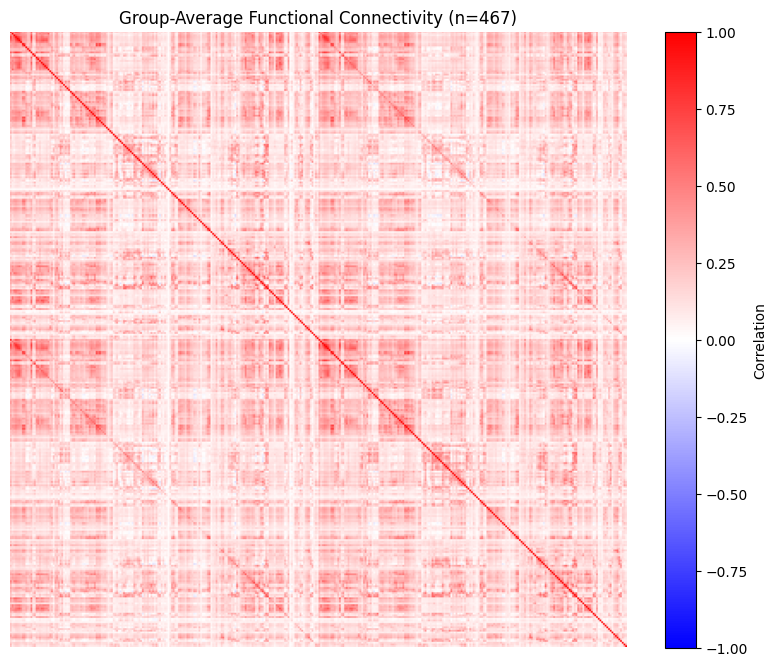

In [16]:
group_fc = FC.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.imshow(group_fc, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.axis("off")
plt.title(f"Group-Average Functional Connectivity (n={FC.shape[0]})")
plt.show()

In [19]:
regions = np.load("regions.npy").T
region_info = dict(name=regions[0].tolist(), network=regions[1], myelin=regions[2].astype(float))